# Asia Fuel Prices — Deep Dive Analysis


## 1. Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.width', 120)
PALETTE_REGION = {'South Asia': '#E63946', 'East Asia': '#457B9D', 'Southeast Asia': '#2A9D8F'}
PALETTE_SUBSIDY = {True: '#F4A261', False: '#2A9D8F'}
BG_COLOR  = '#FAFAFA'
GRID_COLOR = '#E8E8E8'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        False,
    'grid.color':       GRID_COLOR,
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

## 2. Data Loading

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "asia_fuel_prices_detailed.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zkskhurram/world-vs-asia-fuel-prices",
  file_path,)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
print(f'Shape        : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Countries    : {df["country"].nunique()}')
print(f'Sub-Regions  : {df["sub_region"].nunique()} → {list(df["sub_region"].unique())}')
print(f'Price Date   : {df["price_date"].unique()[0]}')
print(f'Missing Values: {df.isnull().sum().sum()}')

Shape        : 22 rows × 16 columns
Countries    : 22
Sub-Regions  : 3 → ['South Asia', 'East Asia', 'Southeast Asia']
Price Date   : 2026-03-23
Missing Values: 0


## 3. Data Overview & Structure

In [ ]:
df.head(10)

,country,sub_region,iso3,gasoline_usd_per_liter,diesel_usd_per_liter,lpg_usd_per_kg,avg_monthly_income_usd,fuel_affordability_index,oil_import_dependency_pct,refinery_capacity_kbpd,ev_adoption_pct,fuel_subsidy_active,subsidy_cost_bn_usd,co2_transport_mt,price_date,gasoline_pct_daily_wage
0,Pakistan,South Asia,PAK,0.820,0.840,0.820,180,7.300,85,450,0.300,True,2.800,42.500,2026-03-23,13.700
1,India,South Asia,IND,1.170,1.060,1.020,280,8.000,85,5340,2.100,False,0.000,320.000,2026-03-23,12.500
2,Bangladesh,South Asia,BGD,1.050,0.910,0.950,160,5.100,100,33,0.100,True,1.200,15.800,2026-03-23,19.700
3,Sri Lanka,South Asia,LKA,1.140,1.020,1.050,210,6.100,100,50,0.200,False,0.000,8.200,2026-03-23,16.300
4,Nepal,South Asia,NPL,1.190,1.080,1.150,120,3.400,100,0,0.500,False,0.000,4.100,2026-03-23,29.800
5,Afghanistan,South Asia,AFG,0.740,0.700,0.750,60,2.700,100,0,0.000,False,0.000,2.800,2026-03-23,37.000
6,China,East Asia,CHN,1.240,1.080,0.780,960,25.800,72,17840,9.400,False,0.000,980.000,2026-03-23,3.900
7,Japan,East Asia,JPN,1.280,1.150,1.150,3200,83.300,99,3520,3.200,True,5.100,185.000,2026-03-23,1.200
8,South Korea,East Asia,KOR,1.420,1.260,0.960,2800,65.700,97,3330,9.800,False,0.000,98.000,2026-03-23,1.500
9,Taiwan,East Asia,TWN,1.040,0.880,0.820,2200,70.500,98,1200,4.500,True,1.800,36.000,2026-03-23,1.400


In [ ]:
type_map = df.dtypes.reset_index()
type_map.columns = ['Column', 'Dtype']
desc = [
    'Country name',
    'Asian sub-region',
    'ISO 3-letter code',
    'Gasoline price (USD / litre)',
    'Diesel price (USD / litre)',
    'LPG price (USD / kg)',
    'Average monthly income (USD)',
    'Fuel affordability index (higher = more affordable)',
    'Oil import dependency (%)',
    'Refinery capacity (thousand barrels/day)',
    'EV adoption rate (%)',
    'Is fuel subsidy active?',
    'Annual subsidy cost (billion USD)',
    'CO₂ from transport (million tonnes)',
    'Price snapshot date',
    'Gasoline price as % of daily wage',
]
type_map['Description'] = desc
print(type_map.to_string(index=False))

                   Column   Dtype                                         Description
                  country  object                                        Country name
               sub_region  object                                    Asian sub-region
                     iso3  object                                   ISO 3-letter code
   gasoline_usd_per_liter float64                        Gasoline price (USD / litre)
     diesel_usd_per_liter float64                          Diesel price (USD / litre)
           lpg_usd_per_kg float64                                LPG price (USD / kg)
   avg_monthly_income_usd   int64                        Average monthly income (USD)
 fuel_affordability_index float64 Fuel affordability index (higher = more affordable)
oil_import_dependency_pct   int64                           Oil import dependency (%)
   refinery_capacity_kbpd   int64            Refinery capacity (thousand barrels/day)
          ev_adoption_pct float64                     

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,22,22,Pakistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_region,22,3,Southeast Asia,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso3,22,22,PAK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasoline_usd_per_liter,22.000,NaN,NaN,NaN,1.058,0.317,0.310,0.935,1.120,1.188,1.880
diesel_usd_per_liter,22.000,NaN,NaN,NaN,0.963,0.251,0.190,0.857,1.015,1.075,1.520
lpg_usd_per_kg,22.000,NaN,NaN,NaN,0.859,0.211,0.280,0.780,0.880,1.005,1.150
avg_monthly_income_usd,22.000,NaN,NaN,NaN,931.818,1279.705,60.000,165.000,295.000,925.000,4800.000
fuel_affordability_index,22.000,NaN,NaN,NaN,33.427,53.340,2.700,5.200,9.150,47.475,236.800
oil_import_dependency_pct,22.000,NaN,NaN,NaN,81.364,27.830,0.000,64.500,98.500,100.000,100.000
refinery_capacity_kbpd,22.000,NaN,NaN,NaN,1695.818,3871.026,0.000,8.250,320.000,1305.000,17840.000


## 4. Data Cleaning & Preprocessing

In [ ]:
df['price_date'] = pd.to_datetime(df['price_date'])

In [ ]:
df['daily_income_usd']         = df['avg_monthly_income_usd'] / 30
df['fuel_cost_10L_pct_income'] = (df['gasoline_usd_per_liter'] * 10) / df['avg_monthly_income_usd'] * 100
df['diesel_gasoline_ratio']    = df['diesel_usd_per_liter'] / df['gasoline_usd_per_liter']
df['subsidy_per_capita_usd']   = (df['subsidy_cost_bn_usd'] * 1e9) / (df['co2_transport_mt'] + 1)  # proxy
df['co2_per_income_unit']      = df['co2_transport_mt'] / (df['avg_monthly_income_usd'] + 1)
df['refinery_self_sufficiency']= 100 - df['oil_import_dependency_pct']

In [ ]:
print('Derived columns added:')
derived_cols = ['daily_income_usd','fuel_cost_10L_pct_income','diesel_gasoline_ratio',
                'refinery_self_sufficiency']
print(df[['country'] + derived_cols].to_string(index=False))

Derived columns added:
    country  daily_income_usd  fuel_cost_10L_pct_income  diesel_gasoline_ratio  refinery_self_sufficiency
   Pakistan             6.000                     4.556                  1.024                         15
      India             9.333                     4.179                  0.906                         15
 Bangladesh             5.333                     6.562                  0.867                          0
  Sri Lanka             7.000                     5.429                  0.895                          0
      Nepal             4.000                     9.917                  0.908                          0
Afghanistan             2.000                    12.333                  0.946                          0
      China            32.000                     1.292                  0.871                         28
      Japan           106.667                     0.400                  0.898                          1
South Korea            

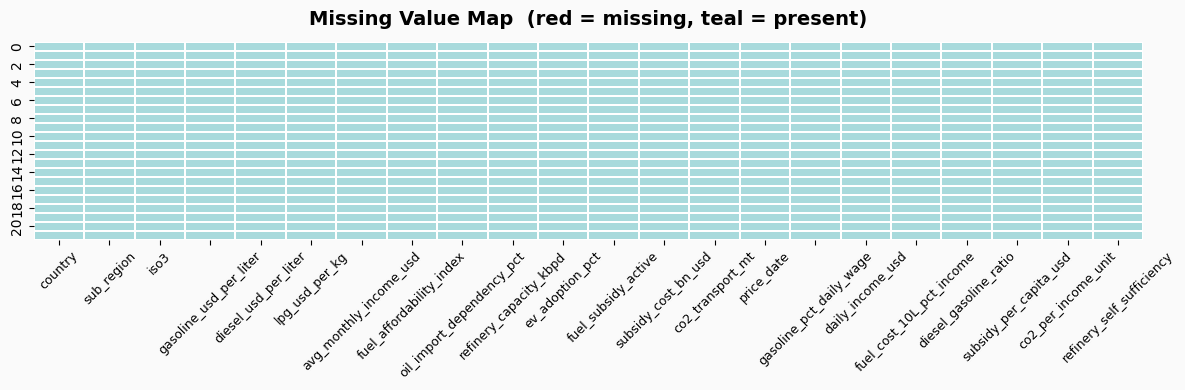

No missing values — clean dataset!


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
miss = df.isnull().astype(int)
sns.heatmap(miss, ax=ax, cbar=False,
            cmap=LinearSegmentedColormap.from_list('miss', ['#A8DADC','#E63946']),
            linewidths=0.3, linecolor='white')
ax.set_title('Missing Value Map  (red = missing, teal = present)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.show()
print('No missing values — clean dataset!')

## 5. Basic Statistical Insights

In [ ]:
num_cols = ['gasoline_usd_per_liter','diesel_usd_per_liter','lpg_usd_per_kg',
            'avg_monthly_income_usd','fuel_affordability_index','gasoline_pct_daily_wage']

stats = df[num_cols].agg(['mean','median','std','min','max']).T
stats.columns = ['Mean','Median','Std Dev','Min','Max']
print('=== Core Statistical Summary ===')
print(stats.round(3).to_string())

=== Core Statistical Summary ===
                            Mean  Median  Std Dev    Min      Max
gasoline_usd_per_liter     1.058   1.120    0.317  0.310    1.880
diesel_usd_per_liter       0.963   1.015    0.251  0.190    1.520
lpg_usd_per_kg             0.859   0.880    0.211  0.280    1.150
avg_monthly_income_usd   931.818 295.000 1279.705 60.000 4800.000
fuel_affordability_index  33.427   9.150   53.340  2.700  236.800
gasoline_pct_daily_wage   12.623  10.900   10.930  0.400   37.000


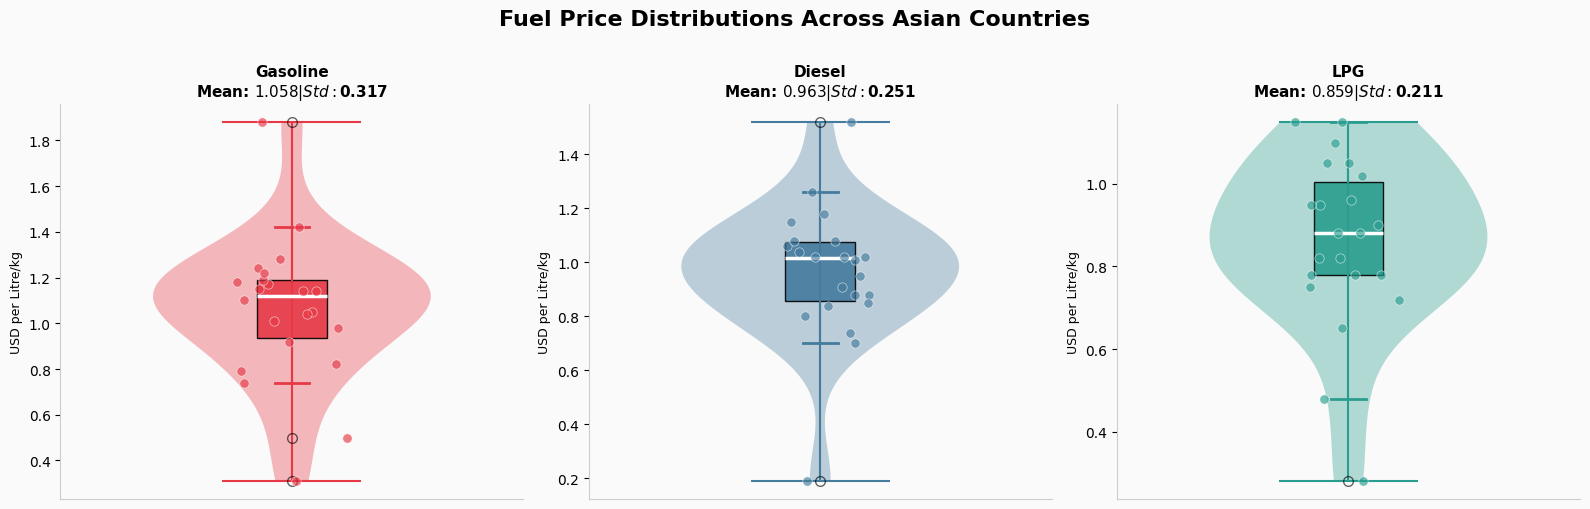

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fuel Price Distributions Across Asian Countries', fontsize=16, fontweight='bold', y=1.01)

fuel_info = [
    ('gasoline_usd_per_liter', 'Gasoline', '#E63946'),
    ('diesel_usd_per_liter',   'Diesel',   '#457B9D'),
    ('lpg_usd_per_kg',         'LPG',      '#2A9D8F'),
]

for ax, (col, label, color) in zip(axes, fuel_info):
    data = df[col]
    parts = ax.violinplot(data, positions=[0], showmedians=False, widths=0.6)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.35)
    parts['cbars'].set_color(color)
    parts['cmaxes'].set_color(color)
    parts['cmins'].set_color(color)
    
    bp = ax.boxplot(data, positions=[0], widths=0.15, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    boxprops=dict(facecolor=color, alpha=0.9),
                    whiskerprops=dict(color=color, linewidth=1.5),
                    capprops=dict(color=color, linewidth=2),
                    flierprops=dict(marker='o', color=color, markersize=7, alpha=0.6))
    
    jitter = np.random.uniform(-0.12, 0.12, len(data))
    ax.scatter(jitter, data, color=color, alpha=0.65, s=45, zorder=5, edgecolors='white', linewidths=0.5)
    
    ax.set_title(f'{label}\nMean: ${data.mean():.3f} | Std: ${data.std():.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('USD per Litre/kg', fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

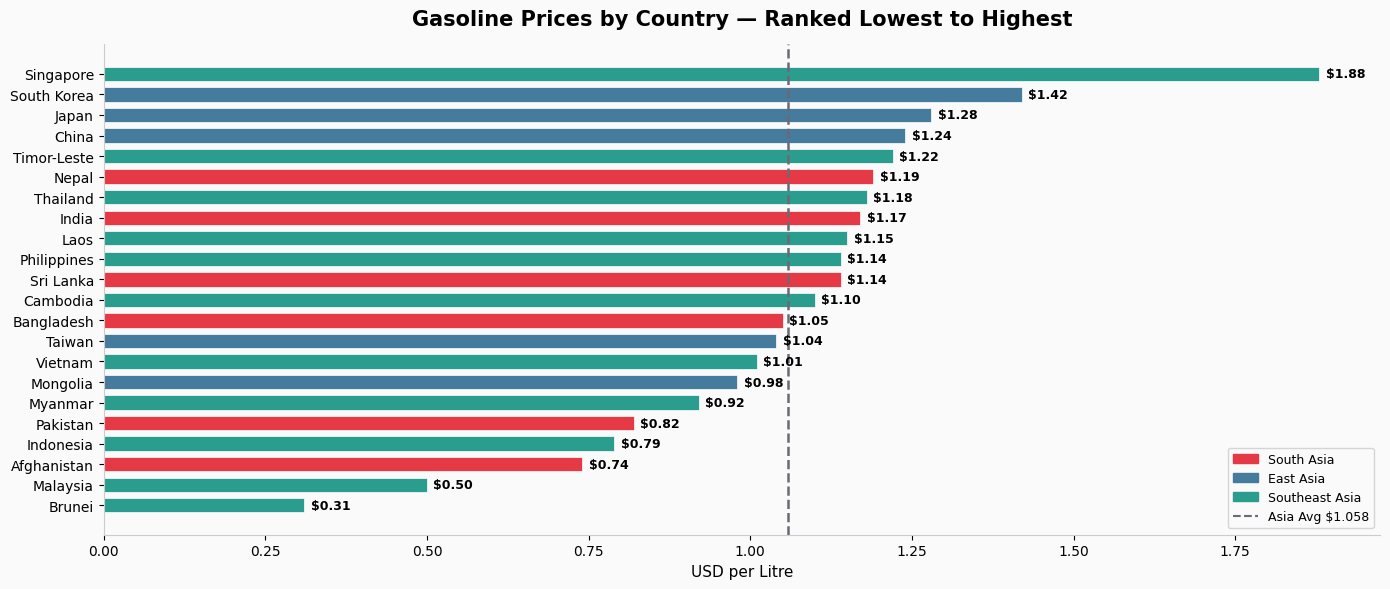

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
sorted_df = df.sort_values('gasoline_usd_per_liter')
colors = [PALETTE_REGION[r] for r in sorted_df['sub_region']]

bars = ax.barh(sorted_df['country'], sorted_df['gasoline_usd_per_liter'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

for bar, val in zip(bars, sorted_df['gasoline_usd_per_liter']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')

avg = df['gasoline_usd_per_liter'].mean()
ax.axvline(avg, color='#6D6875', linestyle='--', linewidth=1.8, label=f'Asia Avg: ${avg:.3f}')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
legend_patches.append(plt.Line2D([0],[0], color='#6D6875', linestyle='--', label=f'Asia Avg ${avg:.3f}'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.8)

ax.set_title('Gasoline Prices by Country — Ranked Lowest to Highest', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('USD per Litre', fontsize=11)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## 6. Regional Comparative Analysis

In [ ]:
region_stats = df.groupby('sub_region').agg(
    countries      = ('country', 'count'),
    avg_gasoline   = ('gasoline_usd_per_liter', 'mean'),
    avg_diesel     = ('diesel_usd_per_liter', 'mean'),
    avg_lpg        = ('lpg_usd_per_kg', 'mean'),
    avg_income_usd = ('avg_monthly_income_usd', 'mean'),
    avg_afford_idx = ('fuel_affordability_index', 'mean'),
    avg_import_dep = ('oil_import_dependency_pct', 'mean'),
    total_co2      = ('co2_transport_mt', 'sum'),
    subsidy_nations= ('fuel_subsidy_active', 'sum'),
    avg_ev_pct     = ('ev_adoption_pct', 'mean'),
).round(2)

print(region_stats.to_string())

                countries  avg_gasoline  avg_diesel  avg_lpg  avg_income_usd  avg_afford_idx  avg_import_dep  total_co2  subsidy_nations  avg_ev_pct
sub_region                                                                                                                                          
East Asia               5         1.190       1.060    0.920        1922.000          52.120          93.200   1302.200                2       5.400
South Asia              6         1.020       0.940    0.960         168.330           5.430          95.000    393.400                2       0.530
Southeast Asia         11         1.020       0.930    0.780         898.180          40.200          68.550    391.400                5       1.180


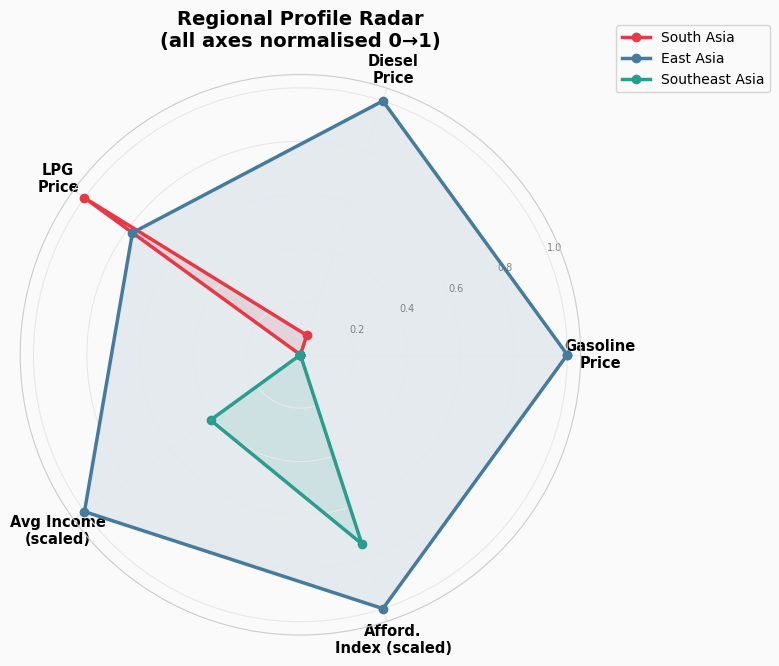

In [ ]:
from matplotlib.patches import FancyArrowPatch

categories = ['Gasoline\nPrice','Diesel\nPrice','LPG\nPrice','Avg Income\n(scaled)','Afford.\nIndex (scaled)']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def normalise(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

radar_df = region_stats[['avg_gasoline','avg_diesel','avg_lpg','avg_income_usd','avg_afford_idx']].copy()
for col in radar_df.columns:
    radar_df[col] = normalise(radar_df[col])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for region, color in PALETTE_REGION.items():
    values = radar_df.loc[region].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=color, label=region)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10.5, fontweight='bold')
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, color='gray')
ax.set_title('Regional Profile Radar\n(all axes normalised 0→1)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.8)

plt.tight_layout()
plt.show()

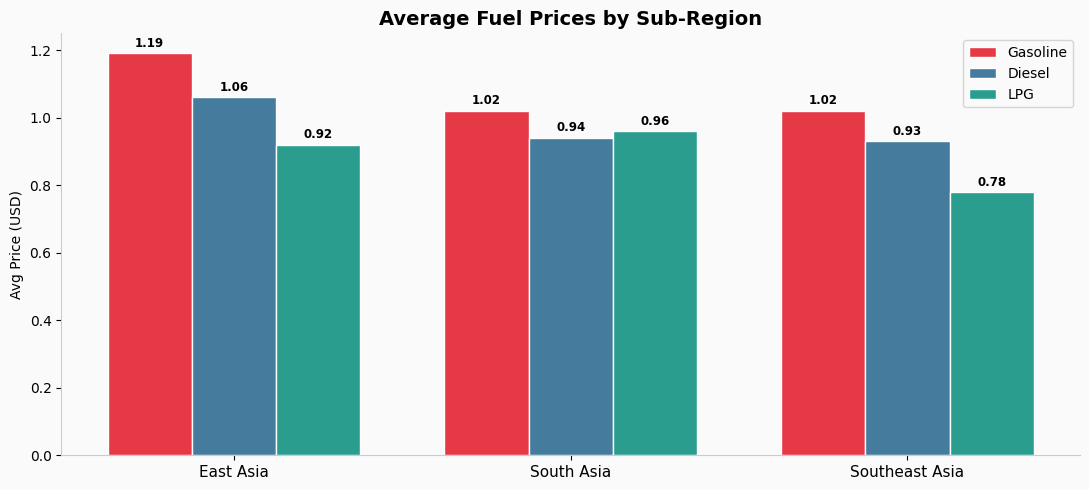

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
regions = region_stats.index.tolist()
x = np.arange(len(regions))
w = 0.25

b1 = ax.bar(x - w, region_stats['avg_gasoline'], w, label='Gasoline', color='#E63946', edgecolor='white')
b2 = ax.bar(x,     region_stats['avg_diesel'],   w, label='Diesel',   color='#457B9D', edgecolor='white')
b3 = ax.bar(x + w, region_stats['avg_lpg'],      w, label='LPG',      color='#2A9D8F', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=11)
ax.set_ylabel('Avg Price (USD)', fontsize=10)
ax.set_title('Average Fuel Prices by Sub-Region', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Fuel Affordability Deep Dive

In [ ]:
print('Top 5 Most Affordable Countries (Fuel Affordability Index):')
print(df.nlargest(5, 'fuel_affordability_index')[['country','sub_region','fuel_affordability_index','avg_monthly_income_usd','gasoline_usd_per_liter']].to_string(index=False))

print('\nTop 5 Least Affordable Countries:')
print(df.nsmallest(5, 'fuel_affordability_index')[['country','sub_region','fuel_affordability_index','avg_monthly_income_usd','gasoline_usd_per_liter']].to_string(index=False))

print('\nGasoline as % of Daily Wage — Top 5 Most Burdened:')
print(df.nlargest(5, 'gasoline_pct_daily_wage')[['country','sub_region','gasoline_pct_daily_wage','avg_monthly_income_usd']].to_string(index=False))

Top 5 Most Affordable Countries (Fuel Affordability Index):
    country     sub_region  fuel_affordability_index  avg_monthly_income_usd  gasoline_usd_per_liter
     Brunei Southeast Asia                   236.800                    2200                   0.310
  Singapore Southeast Asia                    85.100                    4800                   1.880
      Japan      East Asia                    83.300                    3200                   1.280
     Taiwan      East Asia                    70.500                    2200                   1.040
South Korea      East Asia                    65.700                    2800                   1.420

Top 5 Least Affordable Countries:
    country     sub_region  fuel_affordability_index  avg_monthly_income_usd  gasoline_usd_per_liter
Afghanistan     South Asia                     2.700                      60                   0.740
Timor-Leste Southeast Asia                     3.300                     120                   1.

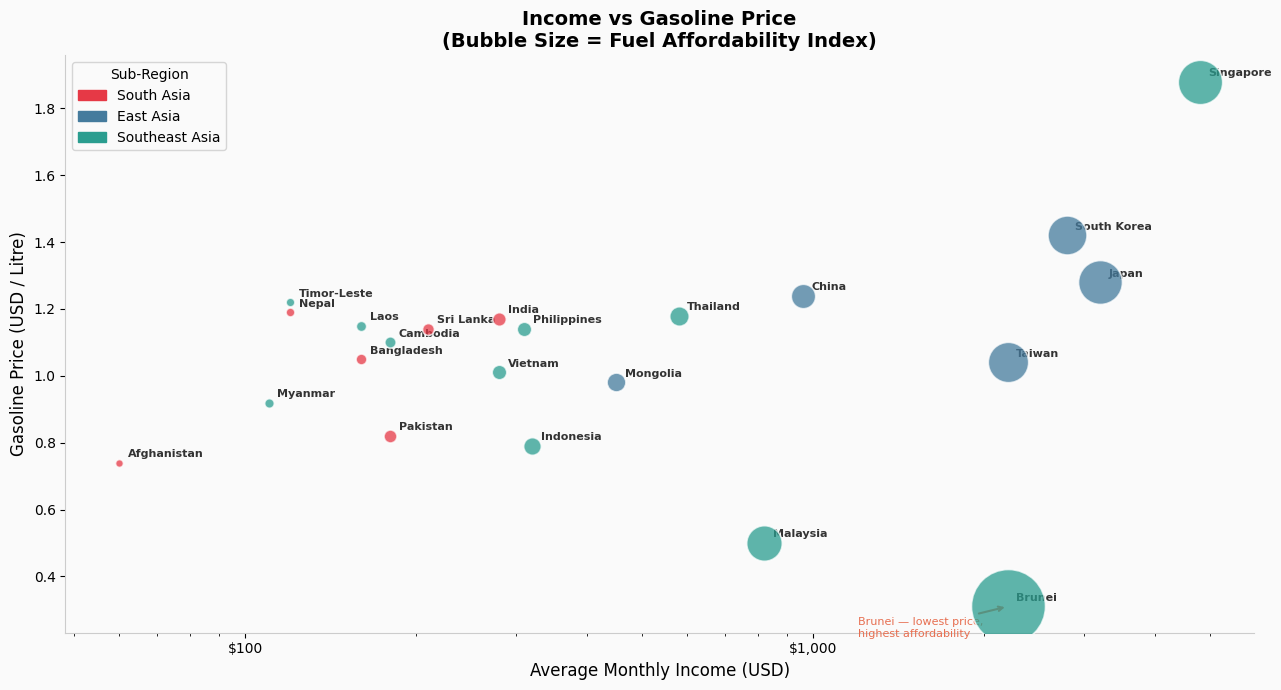

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

for _, row in df.iterrows():
    color = PALETTE_REGION[row['sub_region']]
    size  = row['fuel_affordability_index'] * 12
    ax.scatter(row['avg_monthly_income_usd'], row['gasoline_usd_per_liter'],
               s=size, color=color, alpha=0.75, edgecolors='white', linewidth=1.2, zorder=5)
    ax.annotate(row['country'],
                (row['avg_monthly_income_usd'], row['gasoline_usd_per_liter']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='#333333', fontweight='bold')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
ax.legend(handles=legend_patches, fontsize=10, title='Sub-Region', title_fontsize=10)
ax.set_xlabel('Average Monthly Income (USD)', fontsize=12)
ax.set_ylabel('Gasoline Price (USD / Litre)', fontsize=12)
ax.set_title('Income vs Gasoline Price\n(Bubble Size = Fuel Affordability Index)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

brunei = df[df['country'] == 'Brunei'].iloc[0]
ax.annotate('Brunei — lowest price,\nhighest affordability',
            xy=(brunei['avg_monthly_income_usd'], brunei['gasoline_usd_per_liter']),
            xytext=(1200, 0.22), fontsize=8, color='#E76F51',
            arrowprops=dict(arrowstyle='->', color='#E76F51', lw=1.5))

plt.tight_layout()
plt.show()

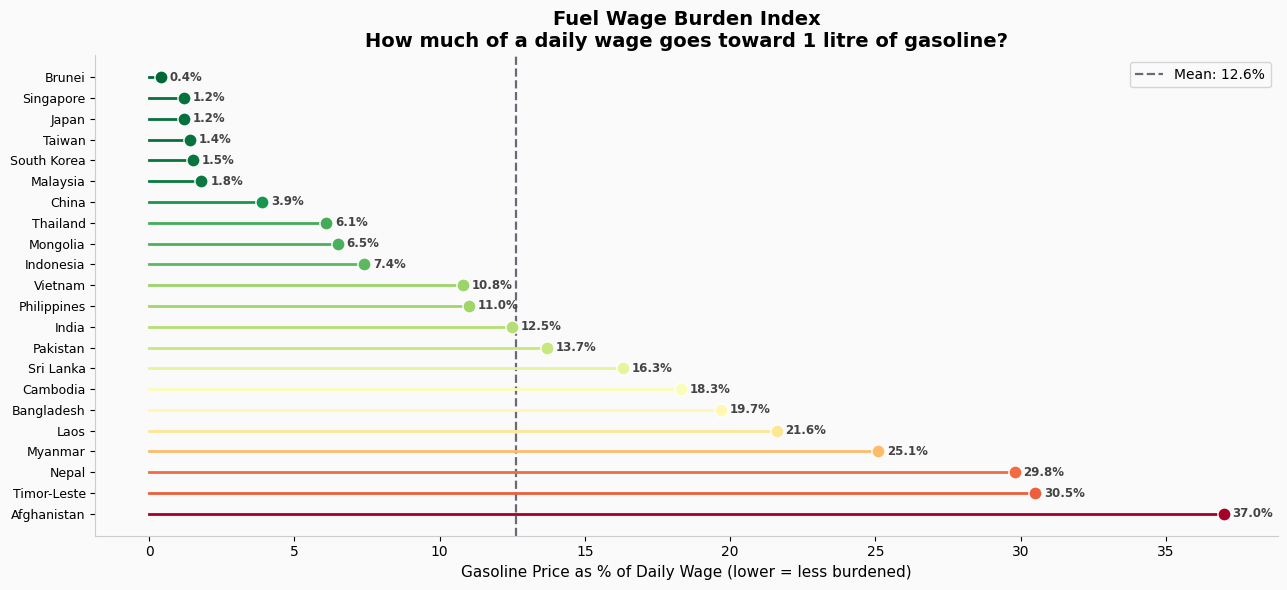

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
sorted_wage = df.sort_values('gasoline_pct_daily_wage', ascending=False)

norm = plt.Normalize(sorted_wage['gasoline_pct_daily_wage'].min(),
                     sorted_wage['gasoline_pct_daily_wage'].max())
cmap = plt.cm.get_cmap('RdYlGn_r')
colors_lol = [cmap(norm(v)) for v in sorted_wage['gasoline_pct_daily_wage']]

for i, (_, row) in enumerate(sorted_wage.iterrows()):
    ax.plot([0, row['gasoline_pct_daily_wage']], [i, i], color=colors_lol[i], linewidth=2, zorder=3)
    ax.scatter(row['gasoline_pct_daily_wage'], i, color=colors_lol[i], s=90, zorder=4,
               edgecolors='white', linewidth=1)
    ax.text(row['gasoline_pct_daily_wage'] + 0.3, i, f"{row['gasoline_pct_daily_wage']}%",
            va='center', fontsize=8.5, fontweight='bold', color='#444')

ax.set_yticks(range(len(sorted_wage)))
ax.set_yticklabels(sorted_wage['country'], fontsize=9)
ax.set_xlabel('Gasoline Price as % of Daily Wage (lower = less burdened)', fontsize=11)
ax.set_title('Fuel Wage Burden Index\nHow much of a daily wage goes toward 1 litre of gasoline?',
             fontsize=14, fontweight='bold')
ax.axvline(df['gasoline_pct_daily_wage'].mean(), color='#6D6875', linestyle='--',
           linewidth=1.6, label=f'Mean: {df["gasoline_pct_daily_wage"].mean():.1f}%')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##  8. Subsidy Economics Analysis

In [ ]:
subsidy_yes = df[df['fuel_subsidy_active'] == True]
subsidy_no  = df[df['fuel_subsidy_active'] == False]

print('=== Subsidy Overview ===')
print(f'Countries WITH subsidy   : {len(subsidy_yes)} ({len(subsidy_yes)/len(df)*100:.0f}%)')
print(f'Countries WITHOUT subsidy: {len(subsidy_no)} ({len(subsidy_no)/len(df)*100:.0f}%)')
print(f'Total annual subsidy cost: ${subsidy_yes["subsidy_cost_bn_usd"].sum():.1f} billion USD')
print()
print('Countries with active subsidies:')
print(subsidy_yes[['country','sub_region','gasoline_usd_per_liter','subsidy_cost_bn_usd',
                   'fuel_affordability_index']].sort_values('subsidy_cost_bn_usd', ascending=False).to_string(index=False))

=== Subsidy Overview ===
Countries WITH subsidy   : 9 (41%)
Countries WITHOUT subsidy: 13 (59%)
Total annual subsidy cost: $35.9 billion USD

Countries with active subsidies:
   country     sub_region  gasoline_usd_per_liter  subsidy_cost_bn_usd  fuel_affordability_index
 Indonesia Southeast Asia                   0.790               12.500                    13.500
  Malaysia Southeast Asia                   0.500                8.400                    54.700
     Japan      East Asia                   1.280                5.100                    83.300
  Thailand Southeast Asia                   1.180                3.200                    16.400
  Pakistan     South Asia                   0.820                2.800                     7.300
    Taiwan      East Asia                   1.040                1.800                    70.500
Bangladesh     South Asia                   1.050                1.200                     5.100
   Myanmar Southeast Asia                   0.920

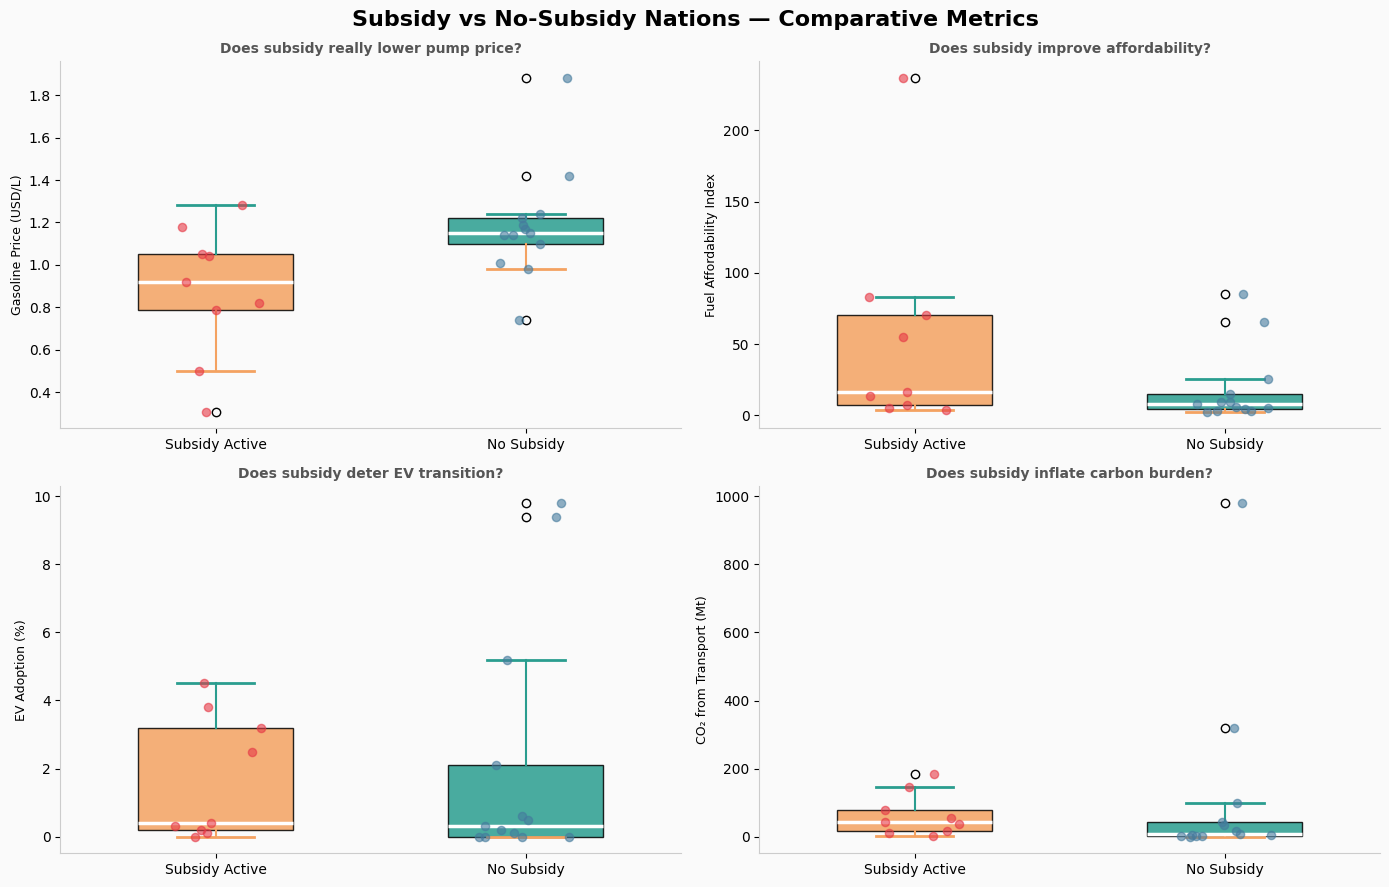

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Subsidy vs No-Subsidy Nations — Comparative Metrics', fontsize=16, fontweight='bold')

metrics = [
    ('gasoline_usd_per_liter',   'Gasoline Price (USD/L)',      'Does subsidy really lower pump price?'),
    ('fuel_affordability_index', 'Fuel Affordability Index',    'Does subsidy improve affordability?'),
    ('ev_adoption_pct',          'EV Adoption (%)',             'Does subsidy deter EV transition?'),
    ('co2_transport_mt',         'CO₂ from Transport (Mt)',     'Does subsidy inflate carbon burden?'),
]

for ax, (col, ylabel, subtitle) in zip(axes.flatten(), metrics):
    data_yes = subsidy_yes[col]
    data_no  = subsidy_no[col]
    
    bp = ax.boxplot([data_yes, data_no], patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=2))
    
    colors_box = ['#F4A261', '#2A9D8F']
    for patch, c in zip(bp['boxes'], colors_box):
        patch.set_facecolor(c); patch.set_alpha(0.85)
    for whisker, c in zip(bp['whiskers'], colors_box * 2):
        whisker.set_color(c)
    for cap, c in zip(bp['caps'], colors_box * 2):
        cap.set_color(c)
    
    jitter_yes = np.random.uniform(-0.15, 0.15, len(data_yes))
    jitter_no  = np.random.uniform(-0.15, 0.15, len(data_no))
    ax.scatter(1 + jitter_yes, data_yes, color='#E63946', alpha=0.6, s=35, zorder=5)
    ax.scatter(2 + jitter_no,  data_no,  color='#457B9D', alpha=0.6, s=35, zorder=5)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Subsidy Active', 'No Subsidy'], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(subtitle, fontsize=10, fontweight='bold', color='#555')

plt.tight_layout()
plt.show()

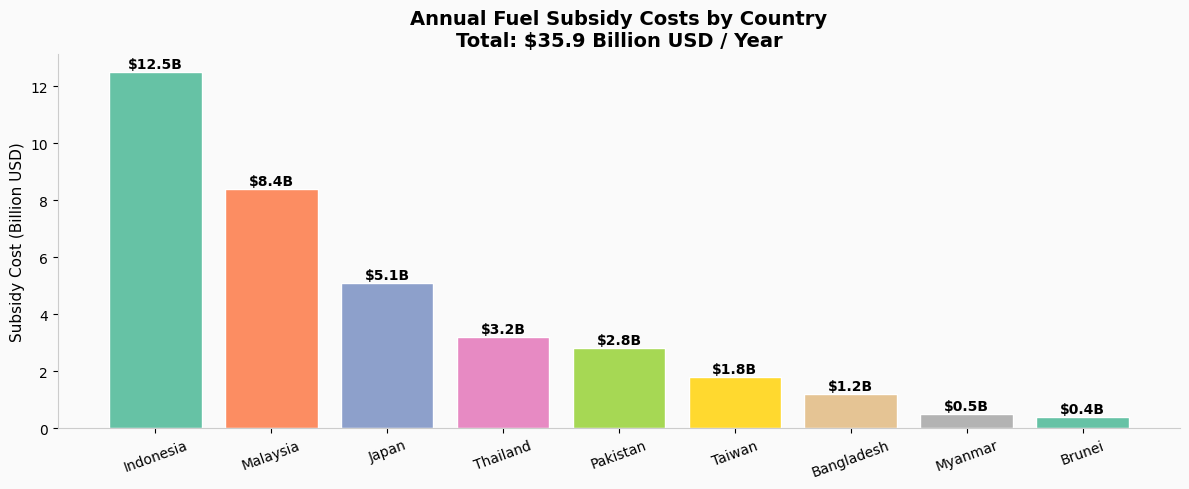

In [ ]:
subsidy_data = subsidy_yes.sort_values('subsidy_cost_bn_usd', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = sns.color_palette('Set2', len(subsidy_data))
bars = ax.bar(subsidy_data['country'], subsidy_data['subsidy_cost_bn_usd'],
              color=bar_colors, edgecolor='white', linewidth=1)

for bar, val in zip(bars, subsidy_data['subsidy_cost_bn_usd']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'${val:.1f}B', ha='center', fontsize=10, fontweight='bold')

total = subsidy_data['subsidy_cost_bn_usd'].sum()
ax.set_title(f'Annual Fuel Subsidy Costs by Country\nTotal: ${total:.1f} Billion USD / Year',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Subsidy Cost (Billion USD)', fontsize=11)
ax.set_xlabel('')
plt.xticks(rotation=20, fontsize=10)
plt.tight_layout()
plt.show()

##  9. EV Adoption & Clean Energy Transition

In [ ]:
print('EV Adoption Rankings:')
ev_sorted = df.sort_values('ev_adoption_pct', ascending=False)
print(ev_sorted[['country','sub_region','ev_adoption_pct','avg_monthly_income_usd',
                 'gasoline_usd_per_liter','fuel_subsidy_active']].to_string(index=False))

EV Adoption Rankings:
    country     sub_region  ev_adoption_pct  avg_monthly_income_usd  gasoline_usd_per_liter  fuel_subsidy_active
South Korea      East Asia            9.800                    2800                   1.420                False
      China      East Asia            9.400                     960                   1.240                False
  Singapore Southeast Asia            5.200                    4800                   1.880                False
     Taiwan      East Asia            4.500                    2200                   1.040                 True
   Thailand Southeast Asia            3.800                     580                   1.180                 True
      Japan      East Asia            3.200                    3200                   1.280                 True
   Malaysia Southeast Asia            2.500                     820                   0.500                 True
      India     South Asia            2.100                     280       

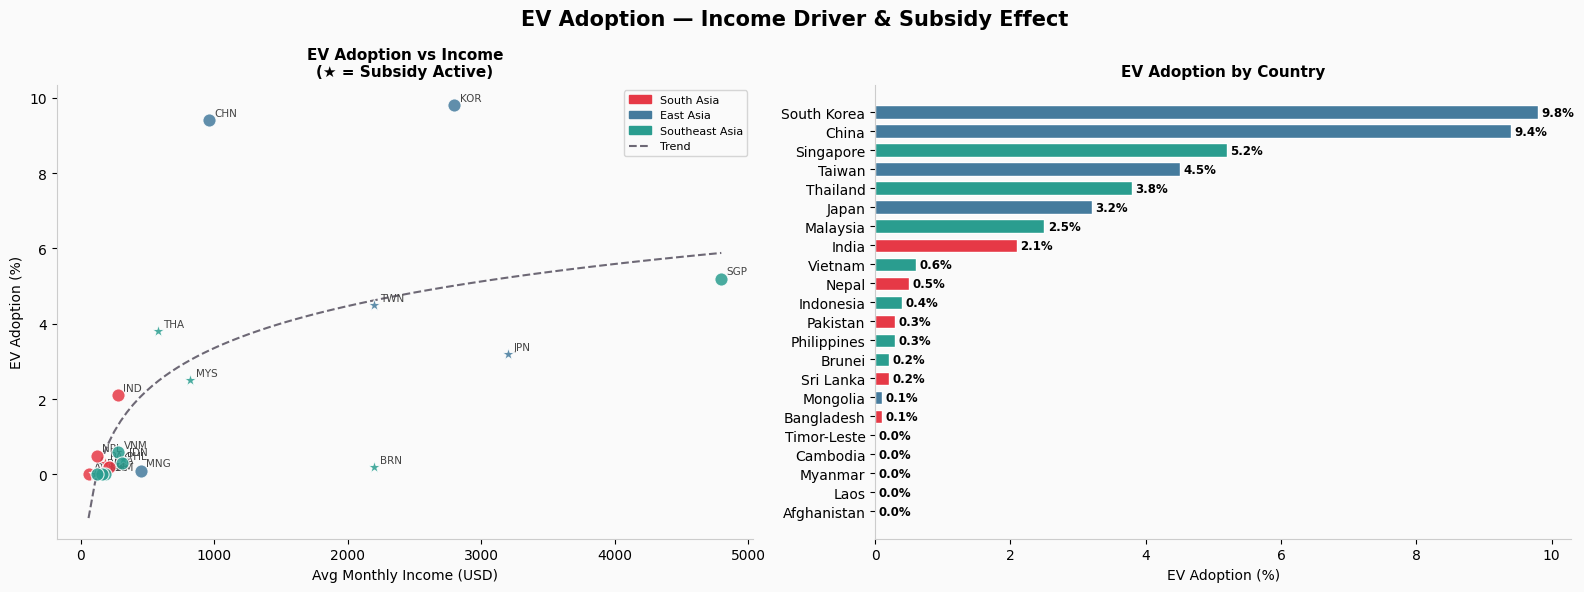

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EV Adoption — Income Driver & Subsidy Effect', fontsize=15, fontweight='bold')

ax = axes[0]
for _, row in df.iterrows():
    color = PALETTE_REGION[row['sub_region']]
    marker = '★' if row['fuel_subsidy_active'] else 'o'
    ax.scatter(row['avg_monthly_income_usd'], row['ev_adoption_pct'],
               color=color, s=90, alpha=0.85,
               marker='*' if row['fuel_subsidy_active'] else 'o',
               edgecolors='white', linewidth=0.8, zorder=5)
    ax.annotate(row['iso3'], (row['avg_monthly_income_usd'], row['ev_adoption_pct']),
                xytext=(4, 3), textcoords='offset points', fontsize=7.5, color='#444')

z = np.polyfit(np.log(df['avg_monthly_income_usd']+1), df['ev_adoption_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['avg_monthly_income_usd'].min(), df['avg_monthly_income_usd'].max(), 100)
ax.plot(x_line, p(np.log(x_line+1)), '--', color='#6D6875', linewidth=1.5, label='Log-linear trend')

ax.set_xlabel('Avg Monthly Income (USD)', fontsize=10)
ax.set_ylabel('EV Adoption (%)', fontsize=10)
ax.set_title('EV Adoption vs Income\n(★ = Subsidy Active)', fontsize=11, fontweight='bold')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],ls='--',color='#6D6875',label='Trend')], fontsize=8)

ax2 = axes[1]
ev_plot = df.sort_values('ev_adoption_pct')
cols = [PALETTE_REGION[r] for r in ev_plot['sub_region']]
bars2 = ax2.barh(ev_plot['country'], ev_plot['ev_adoption_pct'], color=cols, edgecolor='white', height=0.7)
for bar, v in zip(bars2, ev_plot['ev_adoption_pct']):
    ax2.text(v + 0.05, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=8.5, fontweight='bold')
ax2.set_xlabel('EV Adoption (%)', fontsize=10)
ax2.set_title('EV Adoption by Country', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

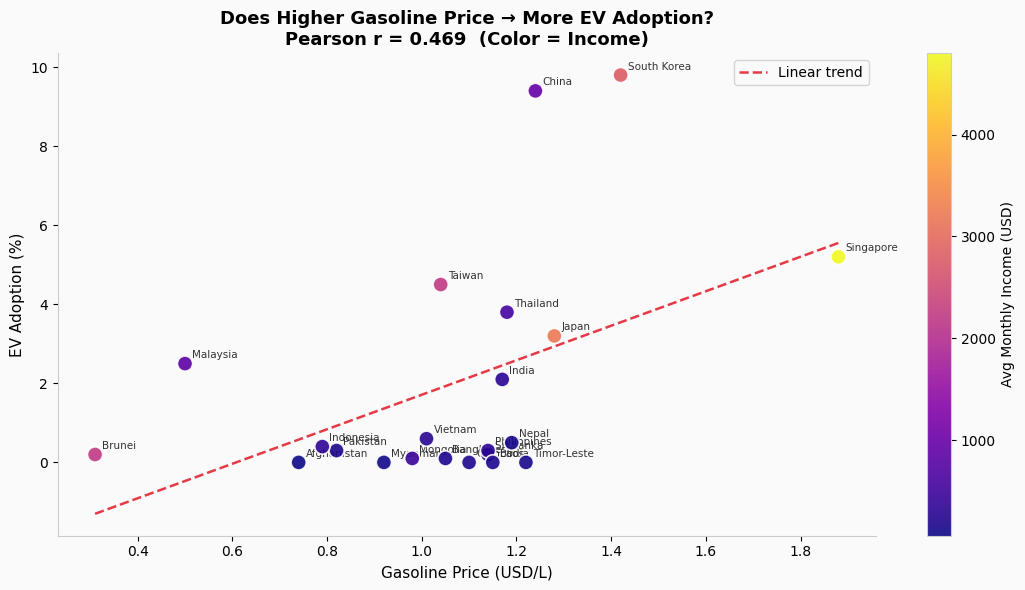


 Insight: r = 0.469 — Income is a stronger EV driver than fuel price alone.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(df['gasoline_usd_per_liter'], df['ev_adoption_pct'],
                c=df['avg_monthly_income_usd'], cmap='plasma', s=120,
                edgecolors='white', linewidth=1.2, alpha=0.9, zorder=5)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Avg Monthly Income (USD)', fontsize=10)

for _, row in df.iterrows():
    ax.annotate(row['country'],
                (row['gasoline_usd_per_liter'], row['ev_adoption_pct']),
                xytext=(5, 4), textcoords='offset points', fontsize=7.5, color='#333')

z = np.polyfit(df['gasoline_usd_per_liter'], df['ev_adoption_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['gasoline_usd_per_liter'].min(), df['gasoline_usd_per_liter'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#E63946', linewidth=1.8, label='Linear trend')

corr = df['gasoline_usd_per_liter'].corr(df['ev_adoption_pct'])
ax.set_title(f'Does Higher Gasoline Price → More EV Adoption?\nPearson r = {corr:.3f}  (Color = Income)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gasoline Price (USD/L)', fontsize=11)
ax.set_ylabel('EV Adoption (%)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'\n Insight: r = {corr:.3f} — Income is a stronger EV driver than fuel price alone.')

## 10. Oil Import Dependency & Energy Security

In [ ]:
print('Fully import-dependent (100%):')
print(df[df['oil_import_dependency_pct'] == 100]['country'].tolist())
print('\nLowest import dependency (most self-sufficient):')
print(df.nsmallest(5,'oil_import_dependency_pct')[['country','oil_import_dependency_pct','refinery_capacity_kbpd']].to_string(index=False))

Fully import-dependent (100%):
['Bangladesh', 'Sri Lanka', 'Nepal', 'Afghanistan', 'Mongolia', 'Philippines', 'Singapore', 'Cambodia', 'Laos', 'Timor-Leste']

Lowest import dependency (most self-sufficient):
  country  oil_import_dependency_pct  refinery_capacity_kbpd
   Brunei                          0                     165
 Malaysia                         35                     770
Indonesia                         42                    1080
  Myanmar                         55                      50
  Vietnam                         60                     360


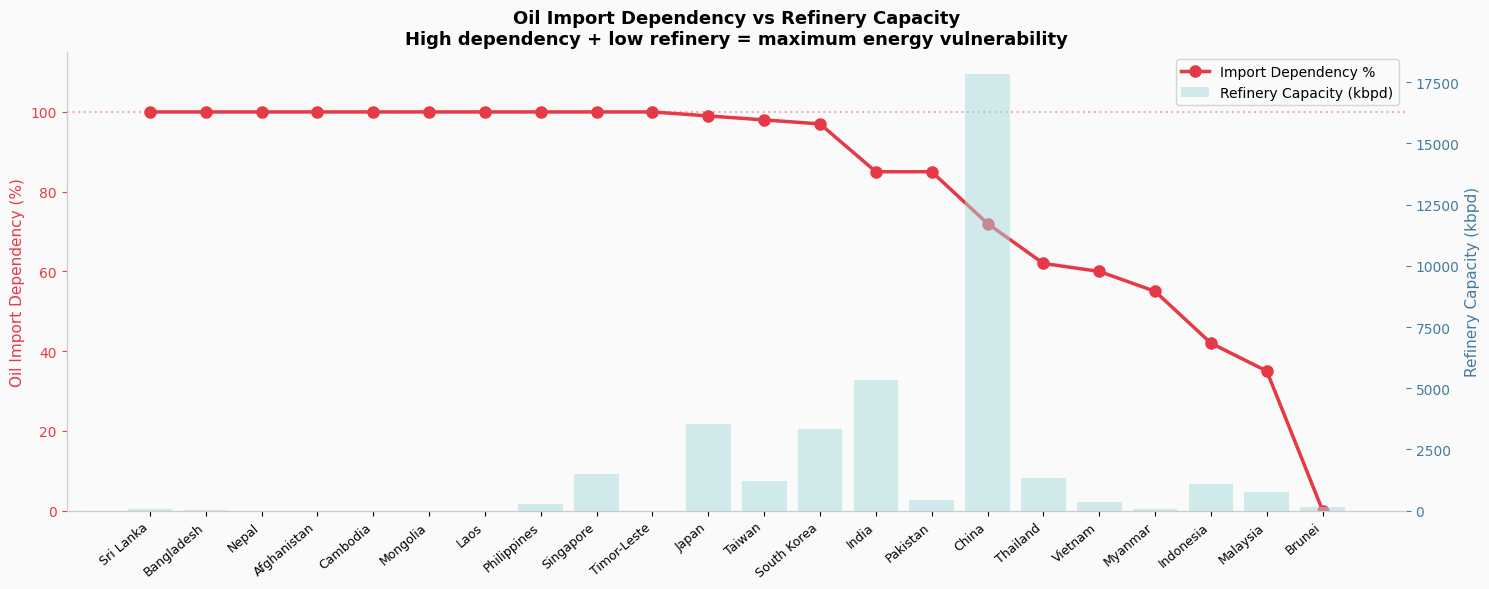

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))
sorted_dep = df.sort_values('oil_import_dependency_pct', ascending=False)

ax2 = ax1.twinx()
x = np.arange(len(sorted_dep))
ax2.bar(x, sorted_dep['refinery_capacity_kbpd'], color='#A8DADC', alpha=0.5,
        label='Refinery Capacity (kbpd)', zorder=2)
ax2.set_ylabel('Refinery Capacity (kbpd)', fontsize=11, color='#457B9D')
ax2.tick_params(axis='y', colors='#457B9D')

ax1.plot(x, sorted_dep['oil_import_dependency_pct'], 'o-',
         color='#E63946', linewidth=2.5, markersize=8, label='Import Dependency %', zorder=5)
ax1.set_ylabel('Oil Import Dependency (%)', fontsize=11, color='#E63946')
ax1.tick_params(axis='y', colors='#E63946')
ax1.set_ylim(0, 115)
ax1.axhline(100, color='#E63946', linestyle=':', alpha=0.4)

ax1.set_xticks(x)
ax1.set_xticklabels(sorted_dep['country'], rotation=40, ha='right', fontsize=9)
ax1.set_title('Oil Import Dependency vs Refinery Capacity\nHigh dependency + low refinery = maximum energy vulnerability',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

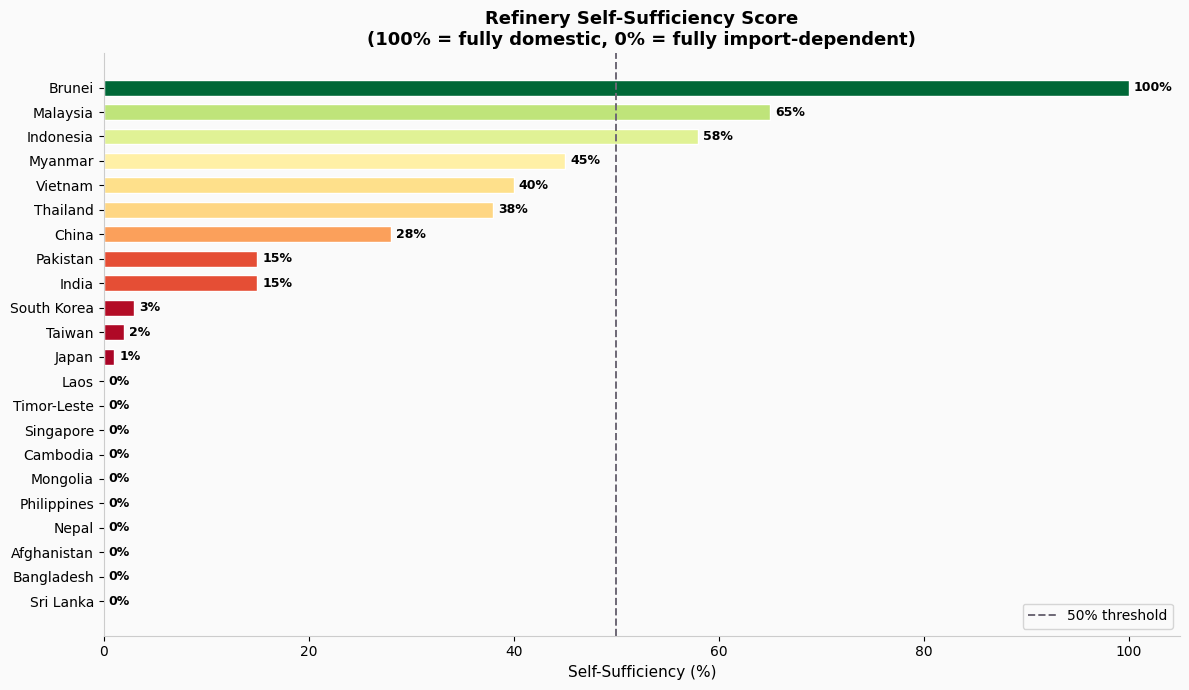

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
sorted_self = df.sort_values('refinery_self_sufficiency', ascending=True)

norm = plt.Normalize(0, 100)
cmap = plt.cm.get_cmap('RdYlGn')
colors_s = [cmap(norm(v)) for v in sorted_self['refinery_self_sufficiency']]

bars = ax.barh(sorted_self['country'], sorted_self['refinery_self_sufficiency'],
               color=colors_s, edgecolor='white', height=0.65)

for bar, v in zip(bars, sorted_self['refinery_self_sufficiency']):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%', va='center', fontsize=9, fontweight='bold')

ax.axvline(50, color='#6D6875', linestyle='--', linewidth=1.4, label='50% threshold')
ax.set_title('Refinery Self-Sufficiency Score\n(100% = fully domestic, 0% = fully import-dependent)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Self-Sufficiency (%)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 11. CO₂ Transport Emissions Landscape

In [ ]:
total_co2 = df['co2_transport_mt'].sum()
print(f'Total transport CO₂ in dataset: {total_co2:.1f} Mt')
print(f'Top 3 emitters account for {df.nlargest(3,"co2_transport_mt")["co2_transport_mt"].sum()/total_co2*100:.1f}% of total')
print()
print(df.sort_values('co2_transport_mt', ascending=False)[['country','co2_transport_mt','avg_monthly_income_usd','ev_adoption_pct']].to_string(index=False))

Total transport CO₂ in dataset: 2087.0 Mt
Top 3 emitters account for 71.2% of total

    country  co2_transport_mt  avg_monthly_income_usd  ev_adoption_pct
      China           980.000                     960            9.400
      India           320.000                     280            2.100
      Japan           185.000                    3200            3.200
  Indonesia           145.000                     320            0.400
South Korea            98.000                    2800            9.800
   Thailand            78.000                     580            3.800
   Malaysia            55.000                     820            2.500
   Pakistan            42.500                     180            0.300
    Vietnam            42.000                     280            0.600
     Taiwan            36.000                    2200            4.500
Philippines            35.000                     310            0.300
  Singapore            17.000                    4800          

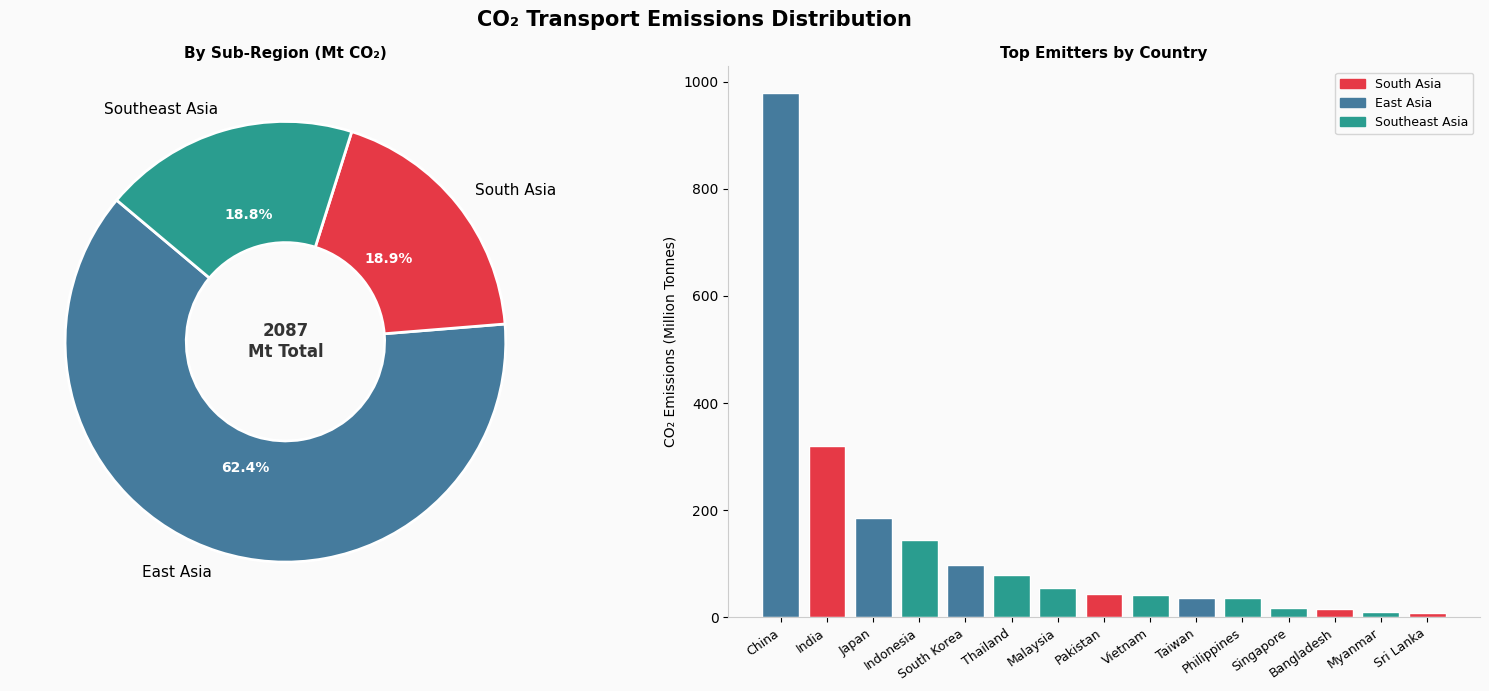

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('CO₂ Transport Emissions Distribution', fontsize=15, fontweight='bold')

ax = axes[0]
region_co2 = df.groupby('sub_region')['co2_transport_mt'].sum()
wedge_colors = [PALETTE_REGION[r] for r in region_co2.index]
wedges, texts, autotexts = ax.pie(
    region_co2.values,
    labels=region_co2.index,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax.set_title('By Sub-Region (Mt CO₂)', fontsize=11, fontweight='bold')
ax.text(0, 0, f'{total_co2:.0f}\nMt Total', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#333')

ax2 = axes[1]
top_co2 = df.sort_values('co2_transport_mt', ascending=False).head(15)
bar_colors = [PALETTE_REGION[r] for r in top_co2['sub_region']]
ax2.bar(top_co2['country'], top_co2['co2_transport_mt'],
        color=bar_colors, edgecolor='white')
ax2.set_ylabel('CO₂ Emissions (Million Tonnes)', fontsize=10)
ax2.set_title('Top Emitters by Country', fontsize=11, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
ax2.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.show()

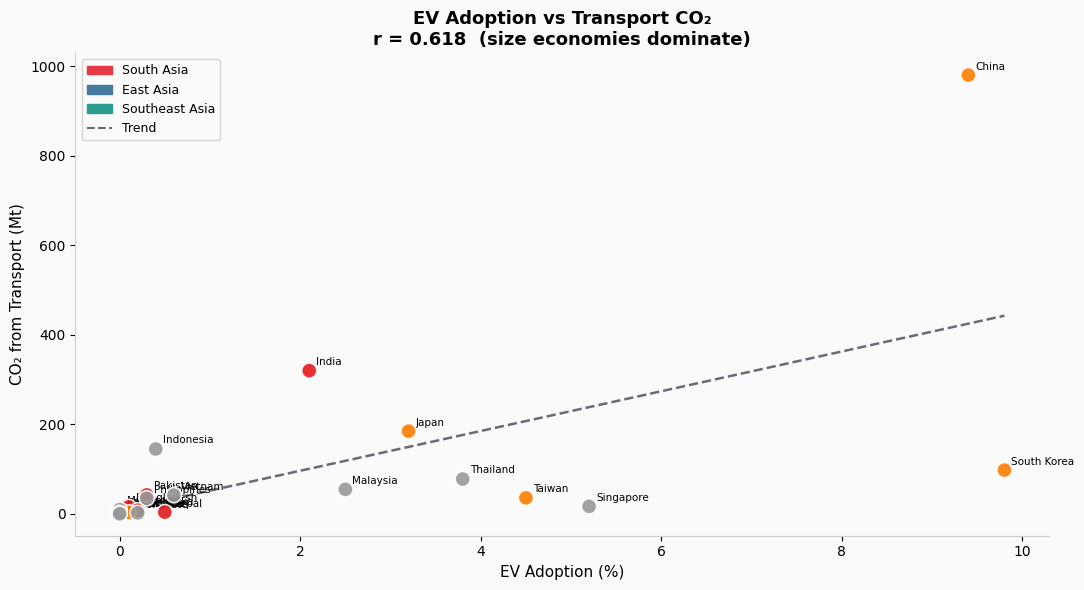


Insight: Large economies (China, India) have both high EV% AND high absolute CO₂ —
   proving that EV adoption rate alone does not reduce absolute emissions at scale.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(df['ev_adoption_pct'], df['co2_transport_mt'],
                c=[list(PALETTE_REGION.keys()).index(r) for r in df['sub_region']],
                cmap=plt.cm.get_cmap('Set1', 3), s=120,
                edgecolors='white', linewidth=1.2, alpha=0.9, zorder=5)

for _, row in df.iterrows():
    ax.annotate(row['country'],
                (row['ev_adoption_pct'], row['co2_transport_mt']),
                xytext=(5, 4), textcoords='offset points', fontsize=7.5)

z = np.polyfit(df['ev_adoption_pct'], df['co2_transport_mt'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['ev_adoption_pct'].min(), df['ev_adoption_pct'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#6D6875', linewidth=1.8, label='Trend')

corr2 = df['ev_adoption_pct'].corr(df['co2_transport_mt'])
ax.set_title(f'EV Adoption vs Transport CO₂\nr = {corr2:.3f}  (size economies dominate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('EV Adoption (%)', fontsize=11)
ax.set_ylabel('CO₂ from Transport (Mt)', fontsize=11)

legend_patches = [mpatches.Patch(color=list(PALETTE_REGION.values())[i], label=k)
                  for i,k in enumerate(PALETTE_REGION.keys())]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],ls='--',color='#6D6875',label='Trend')], fontsize=9)
plt.tight_layout()
plt.show()

print('\nInsight: Large economies (China, India) have both high EV% AND high absolute CO₂ —')
print('   proving that EV adoption rate alone does not reduce absolute emissions at scale.')

##  12. Multi-Dimensional Correlation Analysis

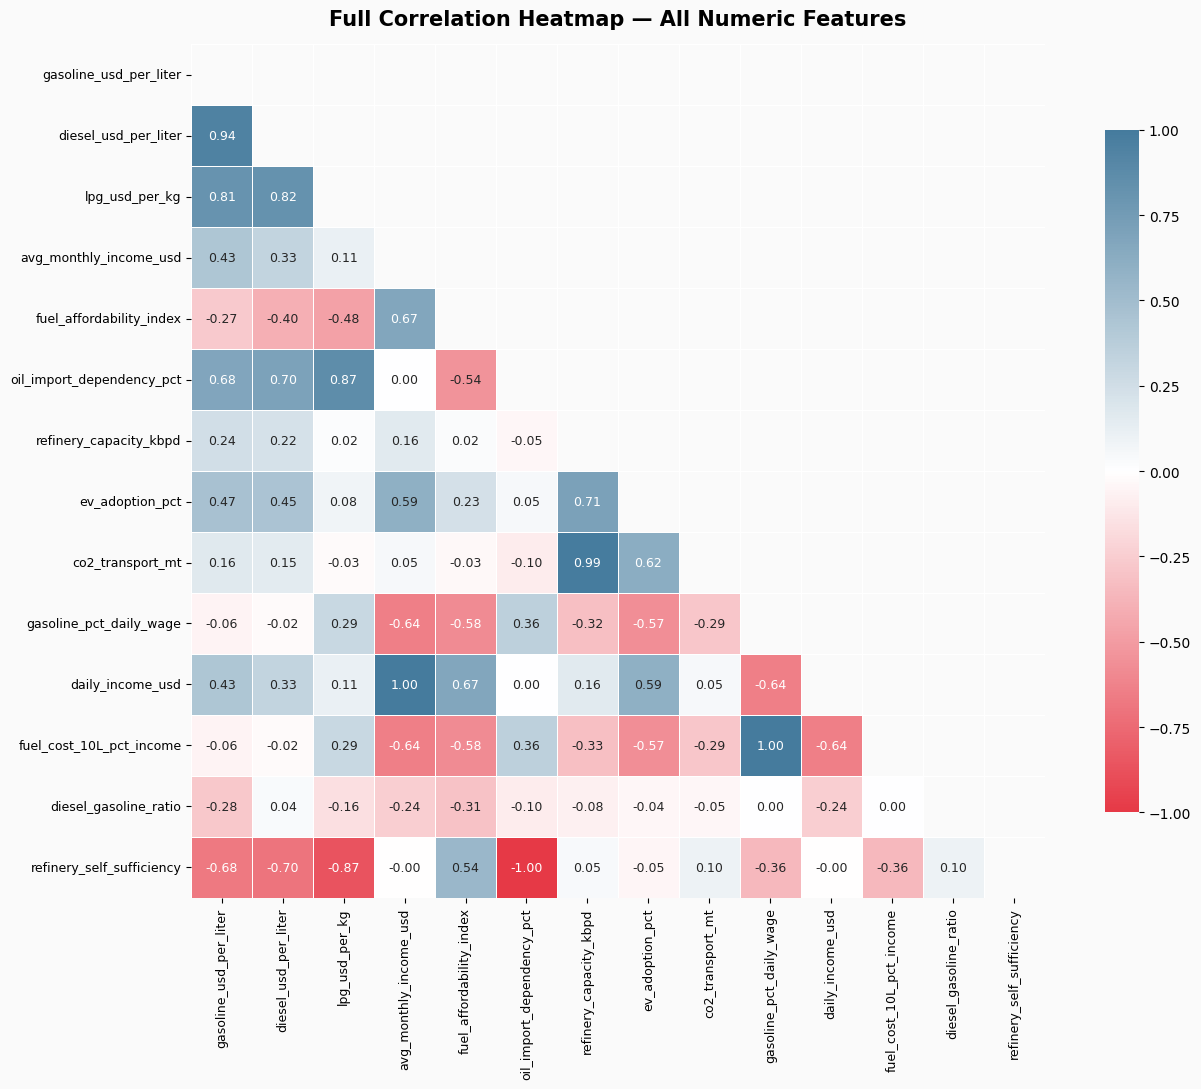

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=['subsidy_cost_bn_usd','subsidy_per_capita_usd','co2_per_income_unit'], errors='ignore')
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
cmap_corr = LinearSegmentedColormap.from_list('corr', ['#E63946','#FFFFFF','#457B9D'])

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap=cmap_corr, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8}
)

ax.set_title('Full Correlation Heatmap — All Numeric Features', fontsize=15, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

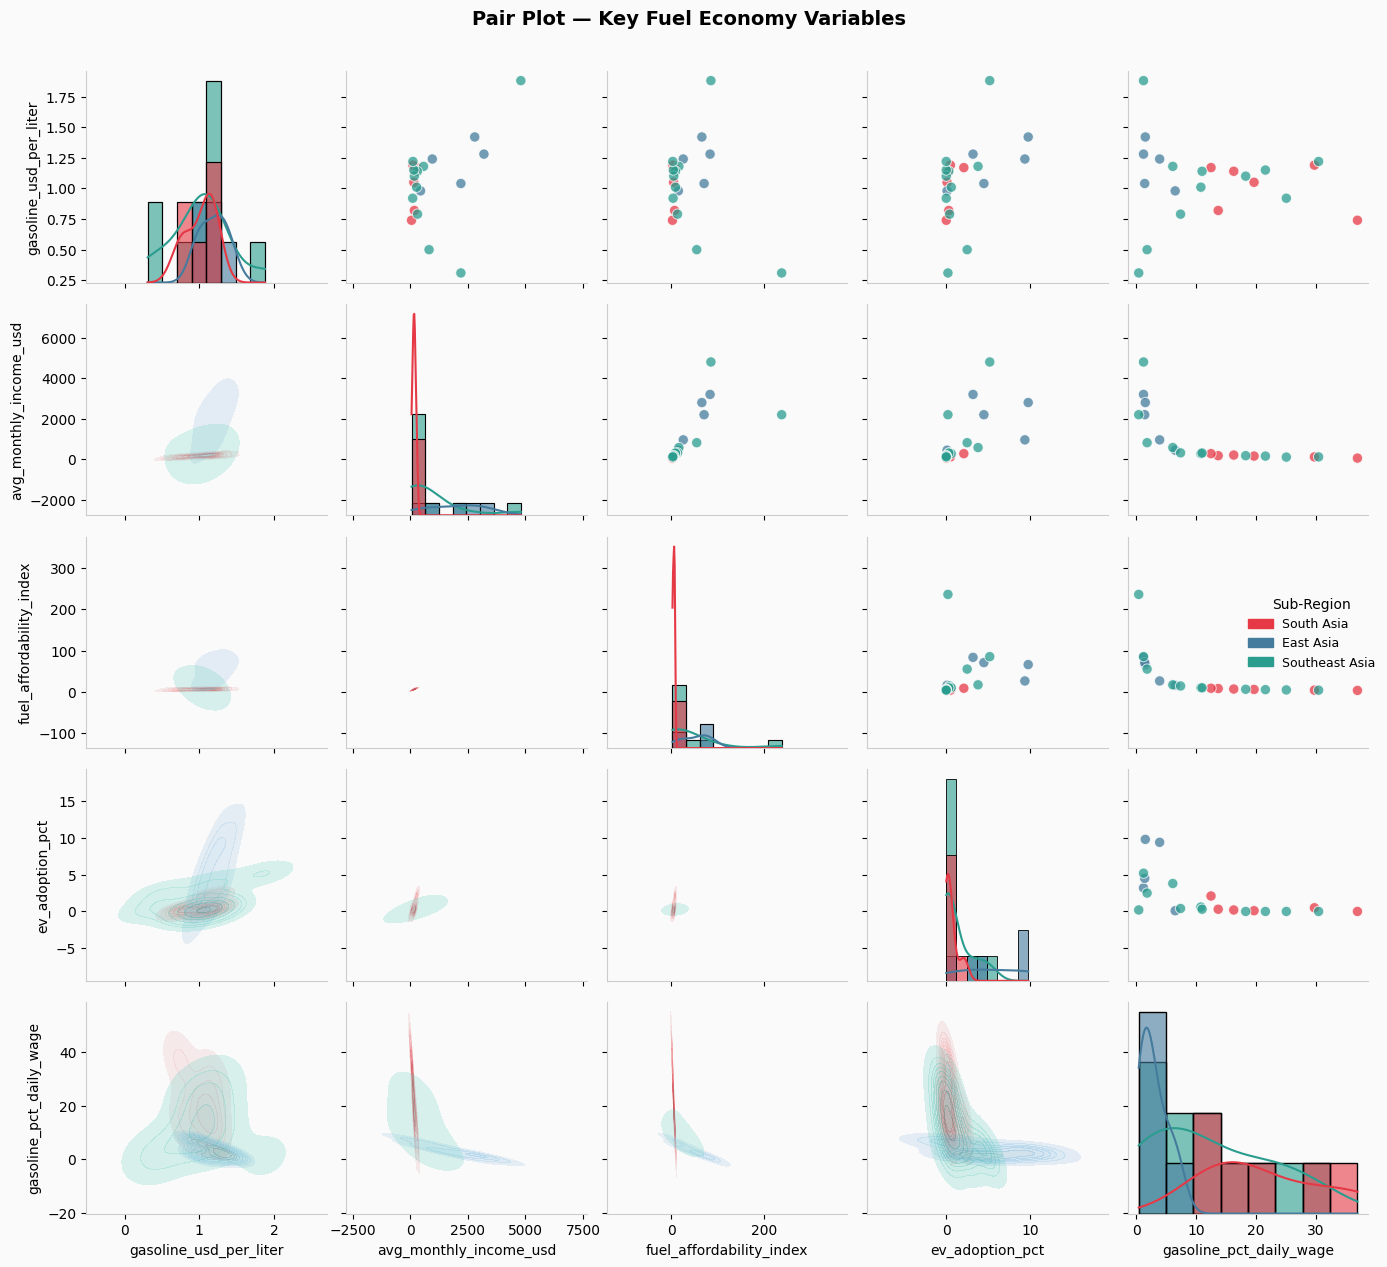

In [ ]:
top5_cols = ['gasoline_usd_per_liter','avg_monthly_income_usd',
             'fuel_affordability_index','ev_adoption_pct','gasoline_pct_daily_wage']

pair_df = df[top5_cols + ['sub_region']].copy()
palette_list = list(PALETTE_REGION.values())
region_order = list(PALETTE_REGION.keys())

g = sns.PairGrid(pair_df, hue='sub_region', hue_order=region_order,
                 palette=PALETTE_REGION, diag_sharey=False)
g.map_upper(sns.scatterplot, alpha=0.75, s=55, edgecolor='white', linewidth=0.7)
g.map_lower(sns.kdeplot, fill=True, alpha=0.25, warn_singular=False)
g.map_diag(sns.histplot, kde=True, bins=8, alpha=0.6)
g.add_legend(title='Sub-Region', fontsize=9, title_fontsize=10)
g.figure.suptitle('Pair Plot — Key Fuel Economy Variables', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  13. Composite Vulnerability & Opportunity Indices

In [ ]:
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

df['fvi_import']    = minmax(df['oil_import_dependency_pct'])    # higher = more vulnerable
df['fvi_wage']      = minmax(df['gasoline_pct_daily_wage'])       # higher = more vulnerable
df['fvi_income']    = minmax(1 / (df['avg_monthly_income_usd'] + 1))  # lower income = more vulnerable
df['fvi_ev']        = minmax(1 - df['ev_adoption_pct'] / 100)    # lower EV = more vulnerable
df['fvi_afford']    = minmax(1 / (df['fuel_affordability_index'] + 1))  # lower afford = more vulnerable

df['fuel_vulnerability_index'] = (
    df['fvi_import'] * 0.25 +
    df['fvi_wage']   * 0.30 +
    df['fvi_income'] * 0.20 +
    df['fvi_ev']     * 0.10 +
    df['fvi_afford'] * 0.15
) * 100  # scale to 0-100

print('=== Fuel Vulnerability Index (FVI) ===')
print('Higher = More Vulnerable to Fuel Price Shocks\n')
print(df.sort_values('fuel_vulnerability_index', ascending=False)
      [['country','sub_region','fuel_vulnerability_index',
        'oil_import_dependency_pct','gasoline_pct_daily_wage','avg_monthly_income_usd']]
      .to_string(index=False))

=== Fuel Vulnerability Index (FVI) ===
Higher = More Vulnerable to Fuel Price Shocks

    country     sub_region  fuel_vulnerability_index  oil_import_dependency_pct  gasoline_pct_daily_wage  avg_monthly_income_usd
Afghanistan     South Asia                   100.000                        100                   37.000                      60
Timor-Leste Southeast Asia                    82.501                        100                   30.500                     120
      Nepal     South Asia                    81.119                        100                   29.800                     120
       Laos Southeast Asia                    69.625                        100                   21.600                     160
 Bangladesh     South Asia                    67.140                        100                   19.700                     160
    Myanmar Southeast Asia                    65.909                         55                   25.100                     110
   Cambodia

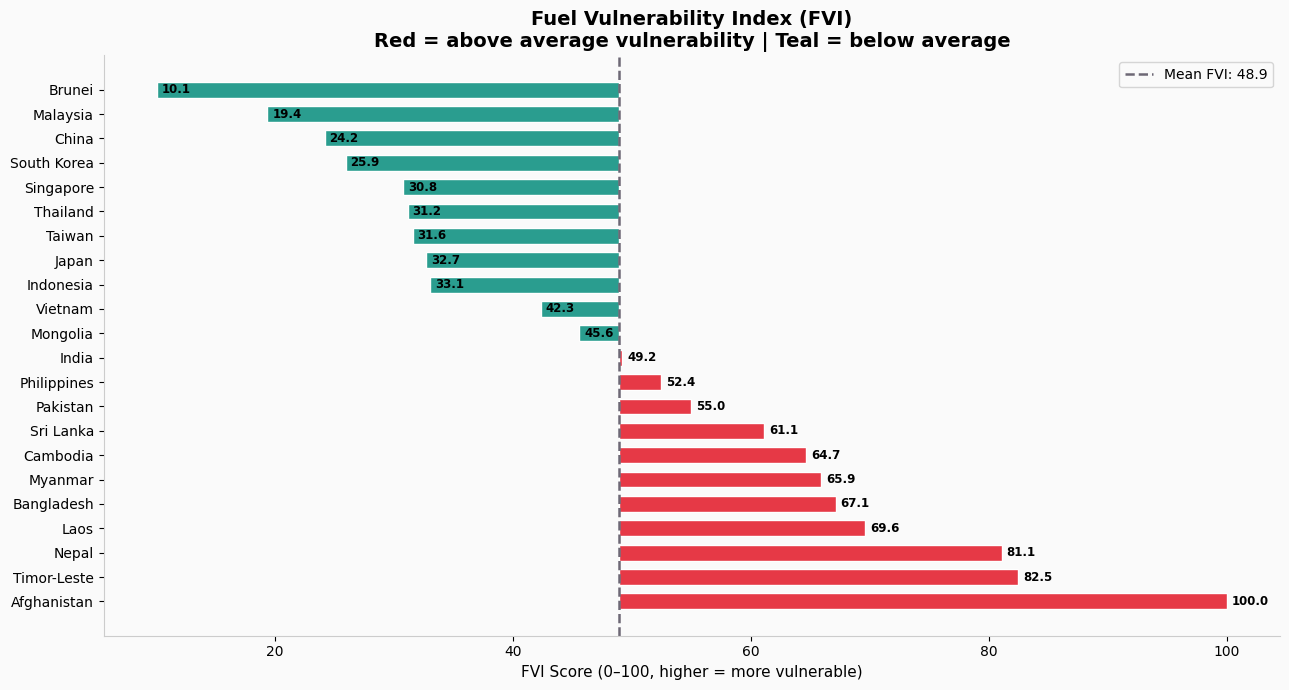

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
fvi_sorted = df.sort_values('fuel_vulnerability_index', ascending=False)
mean_fvi = fvi_sorted['fuel_vulnerability_index'].mean()

colors_fvi = ['#E63946' if v > mean_fvi else '#2A9D8F' for v in fvi_sorted['fuel_vulnerability_index']]

bars = ax.barh(fvi_sorted['country'], fvi_sorted['fuel_vulnerability_index'] - mean_fvi,
               left=mean_fvi, color=colors_fvi, edgecolor='white', height=0.65)
ax.axvline(mean_fvi, color='#6D6875', linewidth=1.8, linestyle='--', label=f'Mean FVI: {mean_fvi:.1f}')

for bar, v in zip(bars, fvi_sorted['fuel_vulnerability_index']):
    ax.text(v + 0.4, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=8.5, fontweight='bold')

ax.set_title('Fuel Vulnerability Index (FVI)\nRed = above average vulnerability | Teal = below average',
             fontsize=14, fontweight='bold')
ax.set_xlabel('FVI Score (0–100, higher = more vulnerable)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

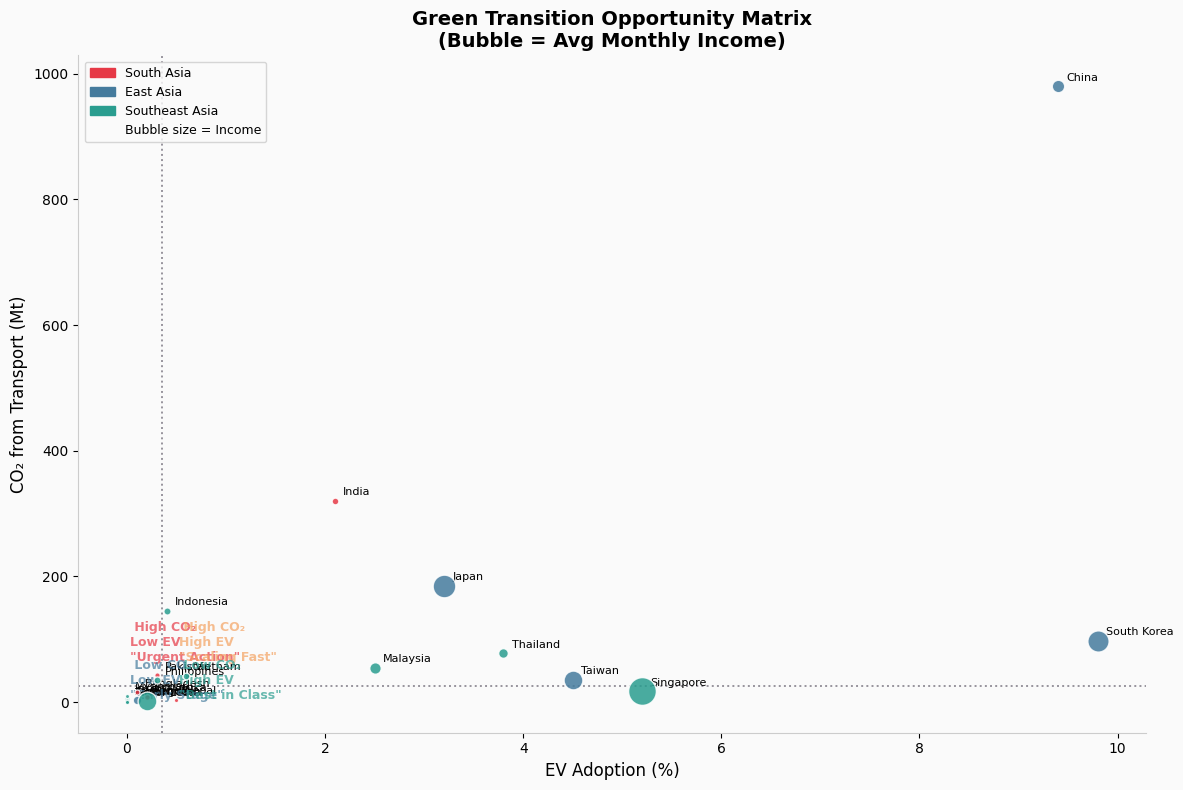

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

ev_med  = df['ev_adoption_pct'].median()
co2_med = df['co2_transport_mt'].median()

for _, row in df.iterrows():
    color = PALETTE_REGION[row['sub_region']]
    ax.scatter(row['ev_adoption_pct'], row['co2_transport_mt'],
               s=row['avg_monthly_income_usd'] / 12, color=color,
               edgecolors='white', linewidth=1, alpha=0.85, zorder=5)
    ax.annotate(row['country'],
                (row['ev_adoption_pct'], row['co2_transport_mt']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)

ax.axvline(ev_med, color='#6D6875', linestyle=':', linewidth=1.4, alpha=0.7)
ax.axhline(co2_med, color='#6D6875', linestyle=':', linewidth=1.4, alpha=0.7)

ax.text(ev_med * 0.1, co2_med * 2.5, ' High CO₂\nLow EV\n"Urgent Action"', fontsize=9,
        color='#E63946', fontweight='bold', alpha=0.7)
ax.text(ev_med * 1.5, co2_med * 2.5, ' High CO₂\nHigh EV\n"Scaling Fast"', fontsize=9,
        color='#F4A261', fontweight='bold', alpha=0.7)
ax.text(ev_med * 0.1, co2_med * 0.2, ' Low CO₂\nLow EV\n"Early Stage"', fontsize=9,
        color='#457B9D', fontweight='bold', alpha=0.7)
ax.text(ev_med * 1.5, co2_med * 0.2, ' Low CO₂\nHigh EV\n"Best in Class"', fontsize=9,
        color='#2A9D8F', fontweight='bold', alpha=0.7)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
legend_patches.append(mpatches.Patch(color='none', label='Bubble size = Income'))
ax.legend(handles=legend_patches, fontsize=9, loc='upper left')

ax.set_xlabel('EV Adoption (%)', fontsize=12)
ax.set_ylabel('CO₂ from Transport (Mt)', fontsize=12)
ax.set_title('Green Transition Opportunity Matrix\n(Bubble = Avg Monthly Income)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

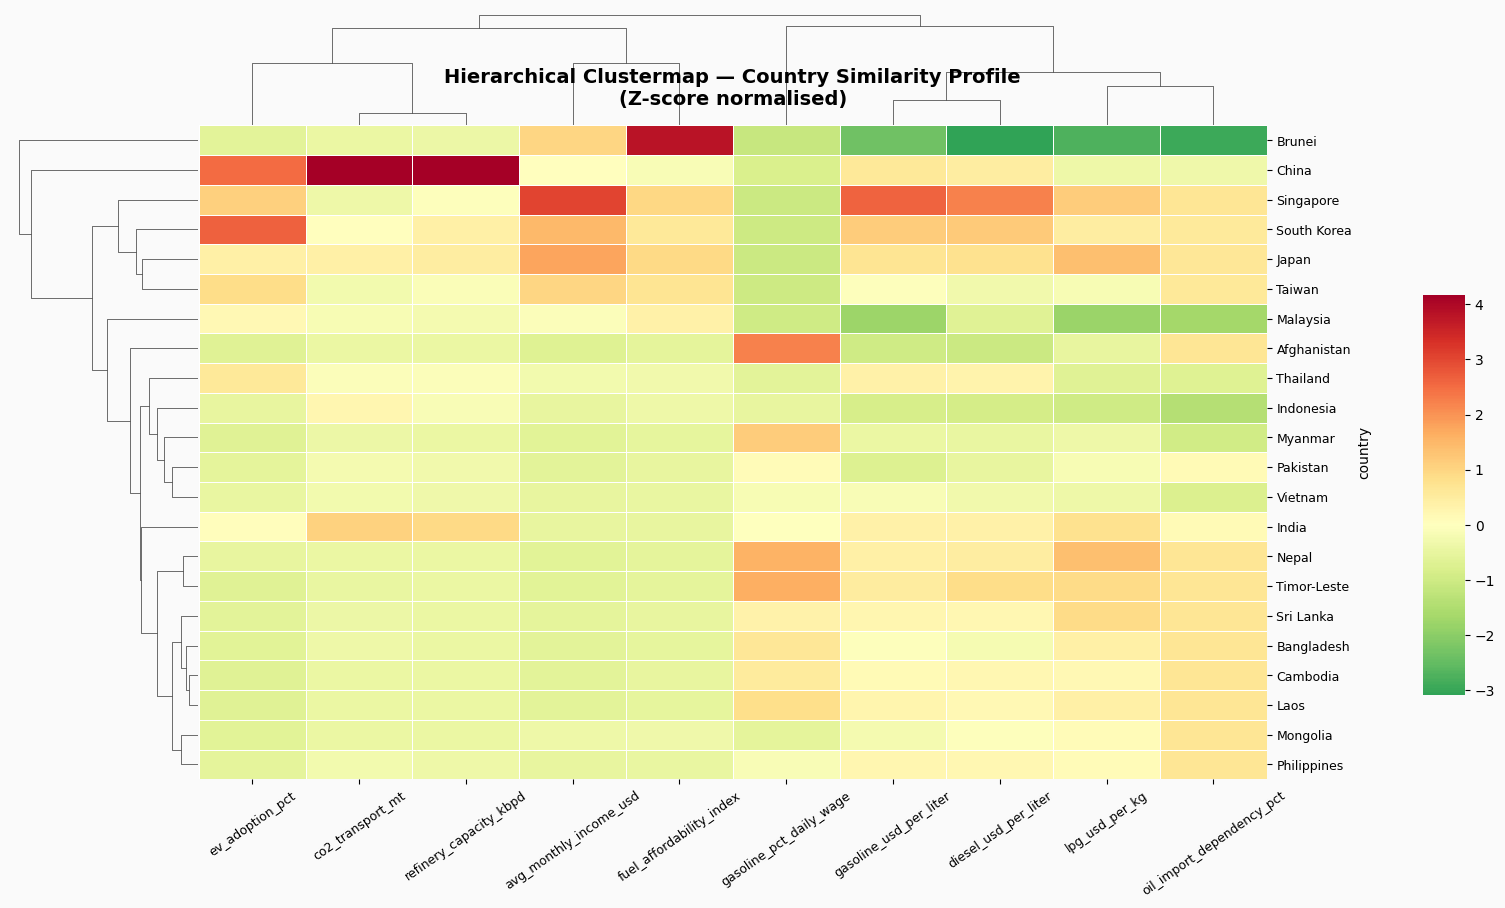

In [ ]:
cluster_df = df.set_index('country')[[
    'gasoline_usd_per_liter','diesel_usd_per_liter','lpg_usd_per_kg',
    'avg_monthly_income_usd','fuel_affordability_index','oil_import_dependency_pct',
    'ev_adoption_pct','co2_transport_mt','gasoline_pct_daily_wage','refinery_capacity_kbpd'
]]
cluster_norm = (cluster_df - cluster_df.mean()) / cluster_df.std()

fig = sns.clustermap(
    cluster_norm, figsize=(14, 10),
    cmap='RdYlGn_r', center=0,
    linewidths=0.4, linecolor='white',
    dendrogram_ratio=0.15,
    annot=False,
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
    yticklabels=True,
    xticklabels=True
)
fig.ax_heatmap.set_title('Hierarchical Clustermap — Country Similarity Profile\n(Z-score normalised)',
                          fontsize=14, fontweight='bold', pad=15)
fig.ax_heatmap.tick_params(axis='x', rotation=35, labelsize=9)
fig.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=9)
plt.show()